In [1]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id

import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, predict_modified_diffusion, predict_diffusion, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM

In [2]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

### Define results directory

In [3]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/diffusion/2022_12_12_02_33_57/standardize/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/encoder/2022_12_04_11_32_01/standardize/'
mobilenet_results_dir = '/home/oogoke/DiffusionSR/runners/runs/clean/lanczos/mobilenet/2022_12_05_10_23_02'


### Plot Train, Test Loss for diffusion

In [4]:
import numpy as np
test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'test_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()
plt.yscale('log')

OSError: /home/oogoke/DiffusionSR/runs/clean/direct/diffusion/2022_12_12_02_33_57/standardize/n_steps_1/test_loss_epoch.txt not found.

In [5]:
p_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/diffusionno_residual'
sub_p_dirs = ['2022_12_19_02_51_24/standardize/n_steps_1', '2022_12_19_02_51_11/standardize/n_steps_1']
timesteps = [1000, 1500]

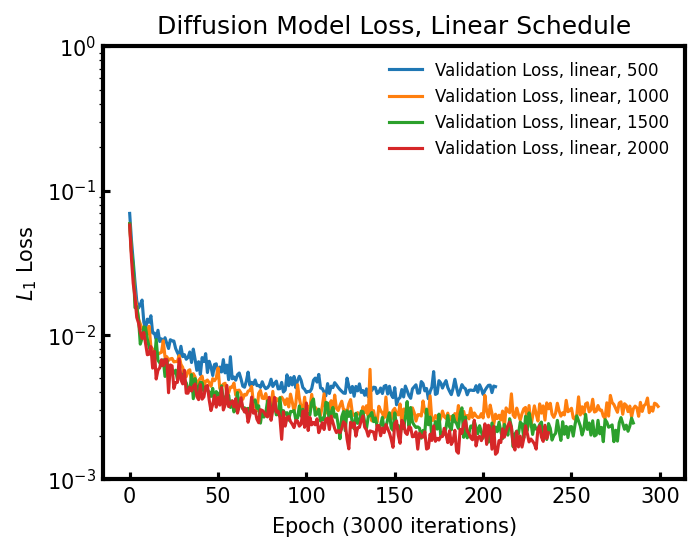

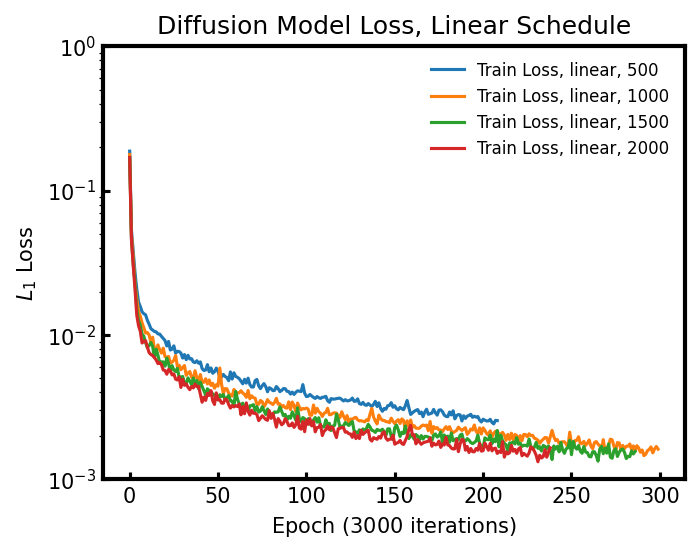

In [6]:

class Simulation():
    def __init__(self, folder, diff_steps, schedule):
        self.folder = folder
        self.diff_steps = diff_steps
        self.schedule = schedule
        self.kp = None
        self.profile = None
        self.max_depth = None
        self.kp_depth = None
    def get_loss_curve(self):
        test_loss = np.loadtxt(os.path.join(self.folder, 'test_loss_epoch.txt'))
        train_loss = np.loadtxt(os.path.join(self.folder, 'loss_epoch.txt'))
        return train_loss, test_loss
simlinear1000 = Simulation(os.path.join(p_dir, '2022_12_19_02_51_24/standardize/n_steps_1'), 1000, 'linear')
simlinear1500 =  Simulation(os.path.join(p_dir, '2022_12_19_02_51_11/standardize/n_steps_1'), 1500, 'linear')
simlinear2000 =  Simulation(os.path.join(p_dir, '2022_12_19_02_50_29/standardize/n_steps_1'), 2000, 'linear')
quadratic2000 = Simulation(os.path.join(p_dir, '2022_12_18_16_13_52/standardize/n_steps_1'), 2000, 'quadratic')
simlinear500 = Simulation(os.path.join(p_dir, '2022_12_18_16_12_08/standardize/n_steps_1'), 500, 'linear')
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
    train_loss, test_loss = sim.get_loss_curve()

    plt.plot(test_loss[:], label = 'Validation Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Linear Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
    train_loss, test_loss = sim.get_loss_curve()

    plt.plot(train_loss[:], label = 'Train Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Linear Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()

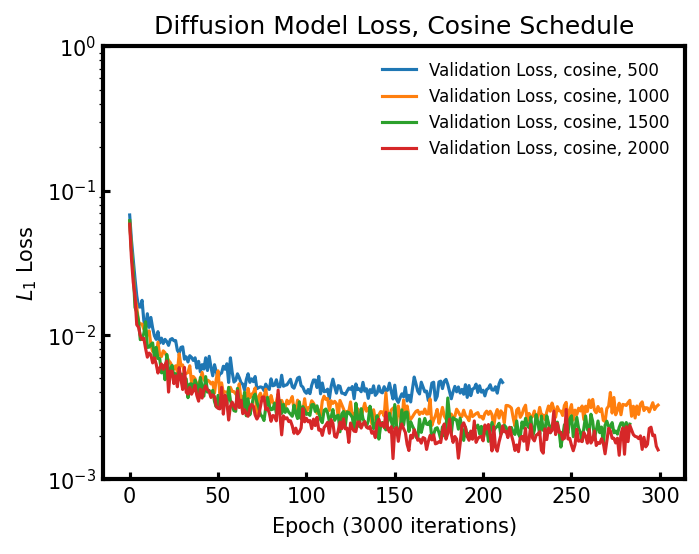

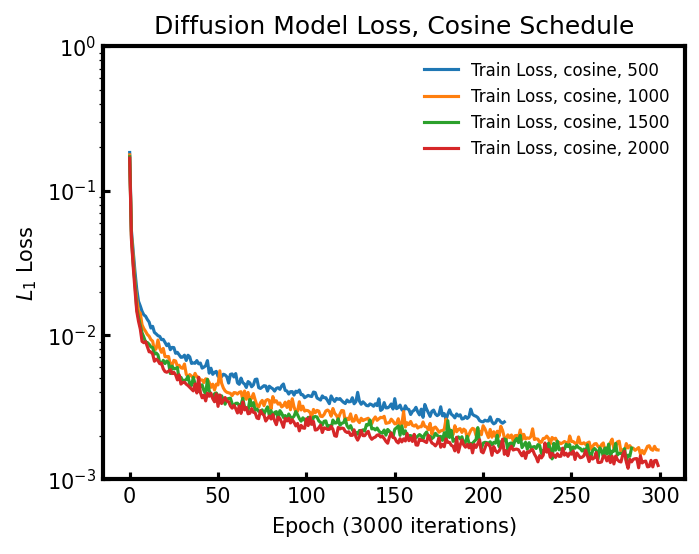

In [7]:

simcosine2000 = Simulation(os.path.join(p_dir, '2022_12_15_17_30_37/standardize/n_steps_1'), 2000, 'cosine')
simcosine1500 =  Simulation(os.path.join(p_dir, '2022_12_19_02_52_54/standardize/n_steps_1'), 1500, 'cosine')
simcosine1000 =  Simulation(os.path.join(p_dir, '2022_12_19_02_52_16/standardize/n_steps_1'), 1000, 'cosine')
quadratic2000 = Simulation(os.path.join(p_dir, '2022_12_18_16_13_52/standardize/n_steps_1'), 2000, 'quadratic')
simcosine500 = Simulation(os.path.join(p_dir, '2022_12_18_16_10_09/standardize/n_steps_1'), 500, 'cosine')

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

for sim in [simcosine500, simcosine1000, simcosine1500, simcosine2000]:
    train_loss, test_loss = sim.get_loss_curve()

    plt.plot(test_loss[:], label = 'Validation Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Cosine Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)


for sim in [simcosine500, simcosine1000, simcosine1500, simcosine2000]:
    train_loss, test_loss = sim.get_loss_curve()

    plt.plot(train_loss[:], label = 'Train Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Cosine Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()

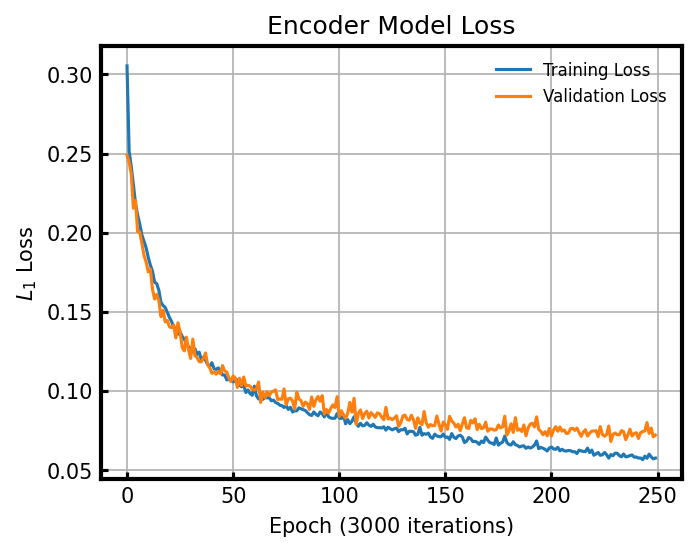

In [8]:
import numpy as np
test_loss = np.loadtxt(os.path.join(encoder_results_dir, 'test_loss.txt'))
train_loss = np.loadtxt(os.path.join(encoder_results_dir, 'train_loss.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Encoder Model Loss')
plt.grid(which = 'major')
frame_tick()

In [9]:
image_size = 80
channels = 1
batch_size =16
train_dataset = TemperatureXZDataset(method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')
test_dataset = TemperatureXZDataset(method ='direct', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')
dev_dataset = TemperatureXZDataset(method = 'direct', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [10]:
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
os.environ['CUDA_VISIBLE_DEVICES']  = "3"
device = 'cuda'
criterion = torch.nn.L1Loss()
lr_enc = load_encoder(encoder_results_dir)
model = load_diffusion(simlinear2000.folder)
batch_size = 16
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)



torch.Size([16, 1, 20, 20])
torch.Size([16, 1, 20, 20]) torch.Size([16, 1, 80, 80]) torch.Size([16, 1, 80, 80])


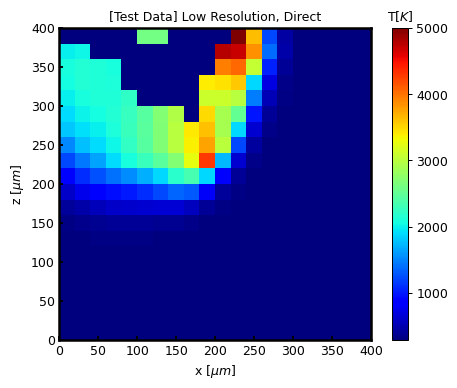

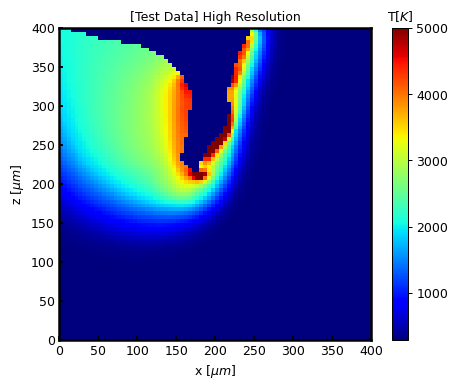

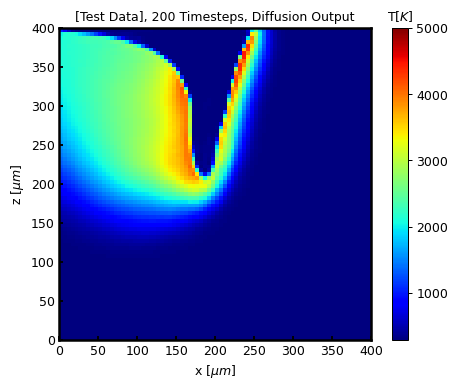

In [11]:
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    print(lr.shape)
    input, result_diffusion, target = predict_lrenc(lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    print(input.shape, result_diffusion.shape, target.shape)
    plot_images(input[0], result_diffusion[0], target[0][0], split = 'Test', modeltype = "Diffusion", timesteps = 200)
    break


### Plot test set melt pools

200 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 200, Schedule = linear


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]/home/oogoke/DiffusionSR/models/diffusion_model.py:284: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x=torch.tensor(x,dtype=torch.float)
sampling loop time step: 100%|██████████| 200/200 [00:12<00:00, 15.80it/s]


torch.Size([16, 1, 20, 20]) (16, 1, 80, 80) torch.Size([16, 1, 80, 80])


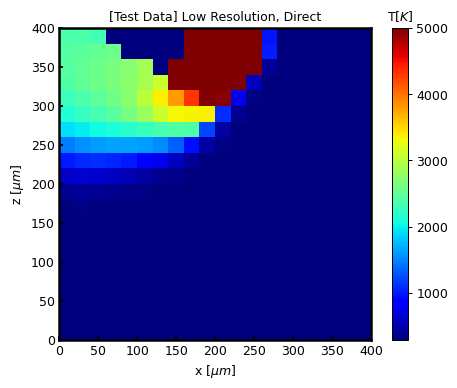

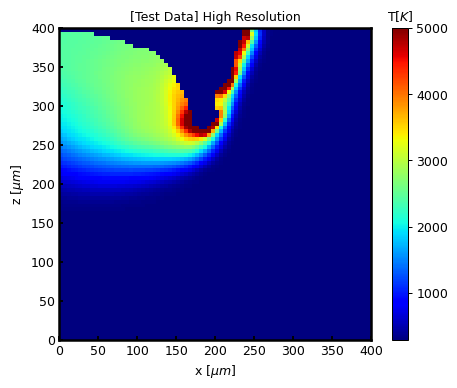

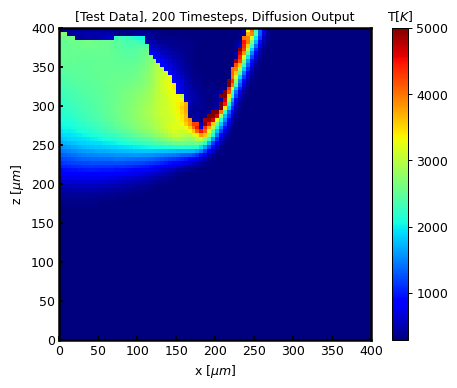

In [12]:
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    
    input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset, timesteps = 200, schedule = 'linear')
    print(input.shape, result_diffusion.shape, target.shape)
    plot_images(input[0], result_diffusion[0], target[0][0], split = 'Test', modeltype = "Diffusion", timesteps = 200)
    break


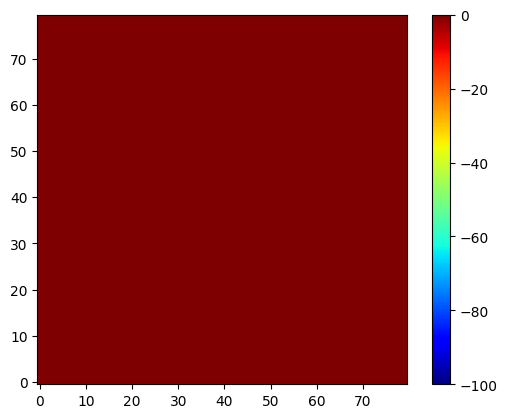

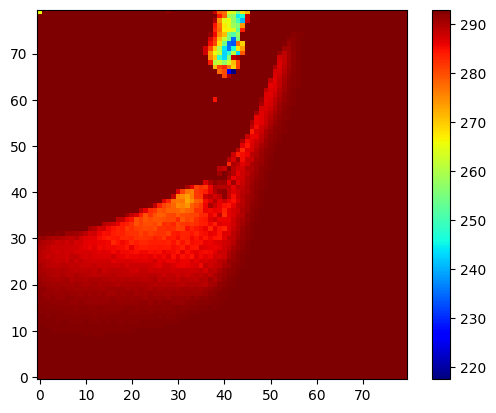

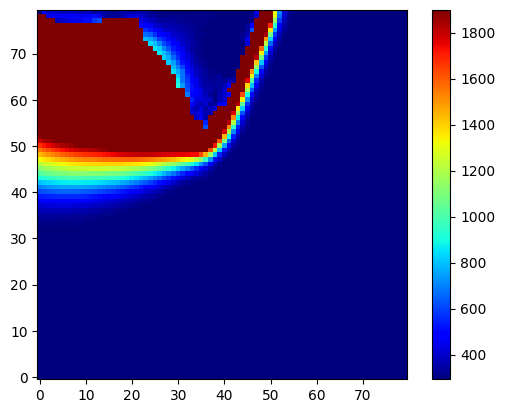

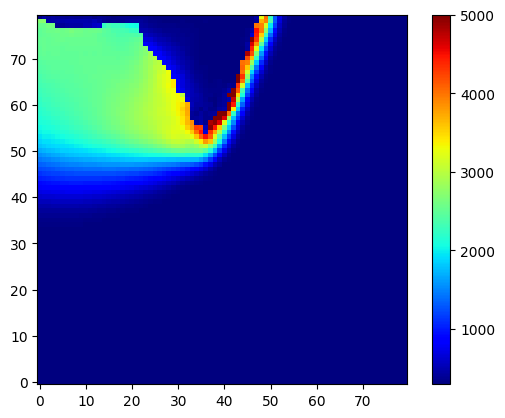

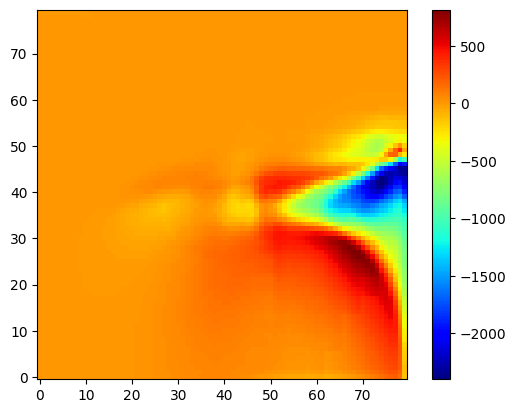

In [13]:
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin = -100, vmax= 0)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmax= 293)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin = 293, vmax= 1900)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin= 293, vmax = 5000)
plt.colorbar()
plt.show()
plt.imshow(dev_dataloader.dataset.unscale_data(res[0,0].T.cpu().numpy(), input_type = 'residual'), cmap = 'jet', origin = 'lower')
plt.colorbar()

### Calculate melt pool and keyhole dimensions

In [9]:
def get_inst_profile(image, mesh = 5):
    image = image[0].T
    print(image.shape)
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            profile.append(binarized.shape[1])
            keyholeprofile.append(binarized.shape[1])
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

In [15]:
# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
sample_times = []
steps_list= []
for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
        oldtime = time.time()
        input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dev_dataset, timesteps =sim.diff_steps)
        # print(result_diffusion.shape)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(sim.diff_steps)
            profile_diff, kp_diff = get_profile(result_diffusion[i])
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i])
            profile_input, kp_input = get_profile(input[i], mesh = 20)
            max_depth_gt.append(5*(80-np.min(profile_gt)))
            max_depth_diff.append(5*(80-np.min(profile_diff)))
            max_depth_input.append(20*(20-np.min(profile_input)))
            kp_depth_gt.append(5*(80-np.min(kp_gt)))
            kp_depth_input.append(20*(20-np.min(kp_input)))
            kp_depth_diff.append(5*(80-np.min(kp_diff)))
        # plt.plot(profile_diff)
        # plt.show()
        if batch_idx > 2:
            break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)



500 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 500, Schedule = linear


sampling loop time step: 100%|██████████| 500/500 [00:31<00:00, 15.72it/s]


500 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 500, Schedule = linear


sampling loop time step: 100%|██████████| 500/500 [00:32<00:00, 15.53it/s]


500 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 500, Schedule = linear


sampling loop time step:  44%|████▍     | 219/500 [00:14<00:18, 15.37it/s]


KeyboardInterrupt: 

In [13]:

def SSIM(op, t, batch_size):
    ssim = 0 
    # print(op.shape, t.shape)
    
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[i][0].detach().cpu().numpy(), t[i][0].detach().cpu().numpy())#, full=True)
        else:
            score = ssim_id(op[i][0], t[i][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim



# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
psnrs_lr = []
psnrs_diff= []

ssims_diff = []
ssims_lr = []

l1_lr = []
l1_diff = []

sample_times = []
steps_list= []
psnr_mean_lr = []
ssim_mean_lr = []
l1_mean_lr = []
ssim_mean_diff = []
psnr_mean_diff = []
l1_mean_diff = []
l1loss = nn.L1Loss()
# sample_diff_steps = [50, 100,200, 500, 1000, 1500, 2000]
# sim = simlinear2000
# for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
#     model = load_diffusion(sim.folder)
diff_steps = 0
# for diff_steps in sample_diff_steps:
kp_depth_diff = []
max_depth_diff = []
max_depth_input= []
kp_depth_input = []
max_depth_gt  = []
kp_depth_gt = []
psnr_batches_lr = []
psnr_batches_diff = []
l1_batches_diff = []
l1_batches_lr = []
ssim_batches_lr = []
ssim_batches_diff = []

for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dataloader):  
    oldtime = time.time()
    input, result_diffusion, target = predict_lrenc(lr_enc, res, hr, lr, upscaled_lr, dev_dataset)
    # print(result_diffusion.shape)
    upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
    lrpsnr = PSNR(upscale, target, target.shape[0]).item()

    diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
    # print(lrpsnr, diffpsnr)
    psnr_batches_diff.append(diffpsnr)
    psnr_batches_lr.append((lrpsnr))
    lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
    diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
    lrl1 = l1loss(upscale, target)
    # print('shape printing here')
    # print(type(result_diffusion), type(target))
    # print(result_diffusion.shape, target.shape)
    diffl1 = l1loss(torch.tensor(result_diffusion), target)
    # print('LR SSIM: ',  SSIM(upscale, target.view(upscale.shape), target.shape[0]))
    # print(result_diffusion.shape, target.shape, 'shapes result diffusion target')
    # print('Diffusion SSIM: ',  SSIM(result_diffusion, target.view(upscale.shape), target.shape[0]))
    ssim_batches_lr.append(lrssim)
    ssim_batches_diff.append(diffssim)
    l1_batches_lr.append(lrl1)
    l1_batches_diff.append(diffl1)
    for i, rd in enumerate(result_diffusion):
        elapsed = time.time() - oldtime
        if batch_idx == 0:
            sample_times.append(elapsed)
            steps_list.append(diff_steps)
        profile_diff, kp_diff = get_profile(result_diffusion[i])
        # print(target.shape)
        profile_gt, kp_gt = get_profile(target[i])
        profile_input, kp_input = get_profile(input[i], mesh = 20)
        # plt.imshow(target[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        # plt.show()
        # plt.imshow(result_diffusion[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        # plt.show()
        # plt.plot(profile_diff)
        # plt.plot(profile_gt)
        # # plt.plot(profile_input)
        # plt.show()


        max_depth_gt.append(5*(80-np.min(profile_gt)))
        max_depth_diff.append(5*(80-np.min(profile_diff)))
        max_depth_input.append(20*(20-np.min(profile_input)))
        kp_depth_gt.append(5*(80-np.min(kp_gt)))
        kp_depth_input.append(20*(20-np.min(kp_input)))
        kp_depth_diff.append(5*(80-np.min(kp_diff)))



    # plt.plot(profile_diff)
    # plt.show()
    # if batch_idx > 9:
    #     break
kp_depth_diffs.append(kp_depth_diff)
max_depth_diffs.append(max_depth_diff)
ssims_diff.append(ssim_batches_diff)
ssims_lr.append(ssim_batches_lr)
l1_lr.append(l1_batches_lr)
psnrs_lr.append(psnr_batches_lr)
psnrs_diff.append(psnr_batches_diff)
l1_diff.append(l1_batches_diff)
psnr_mean_lr.append(np.mean(psnr_batches_lr))
psnr_mean_diff.append(np.mean(psnr_batches_diff))
ssim_mean_diff.append(np.mean(ssim_batches_diff))
ssim_mean_lr.append(np.mean(ssim_batches_lr))
l1_mean_lr.append(np.mean(l1_batches_lr))
l1_mean_diff.append(np.mean(l1_batches_diff))

print(ssim_mean_lr)



/tmp/ipykernel_60287/1515129198.py:84: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diffl1 = l1loss(torch.tensor(result_diffusion), target)


[0.7220449168810281]


200 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 200, Schedule = linear


sampling loop time step: 100%|██████████| 200/200 [00:12<00:00, 15.65it/s]


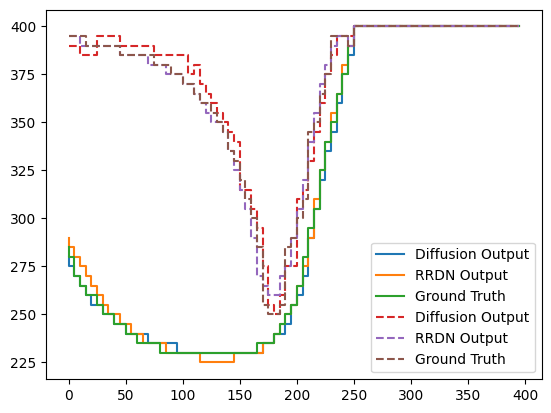

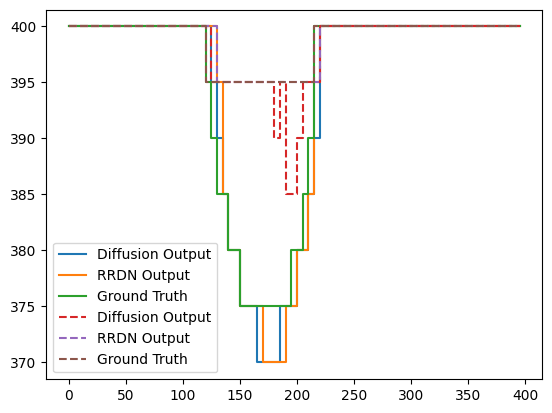

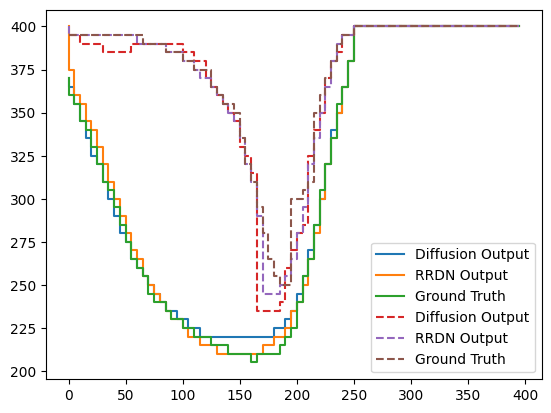

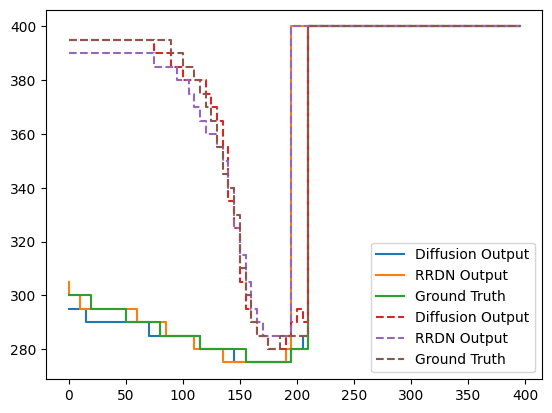

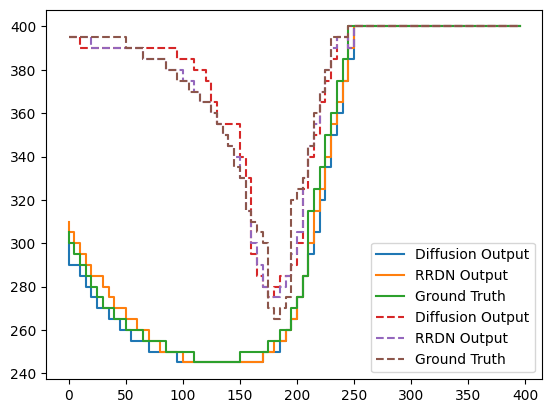

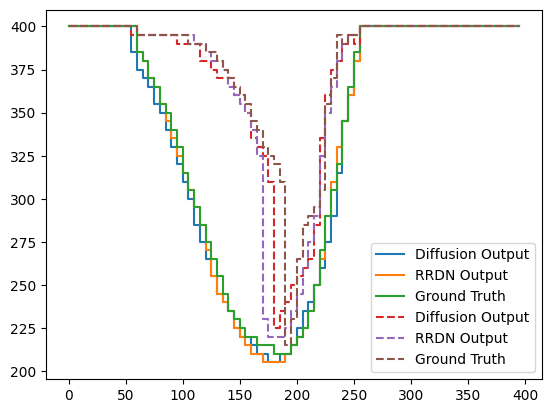

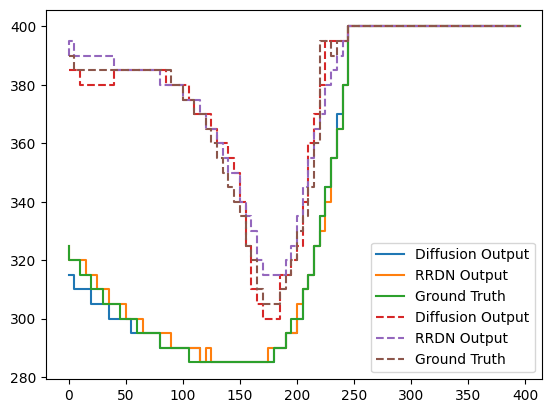

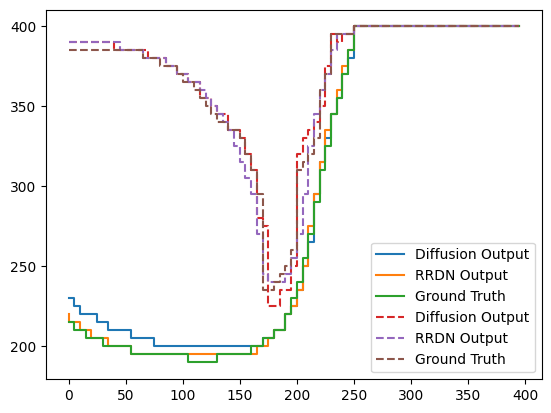

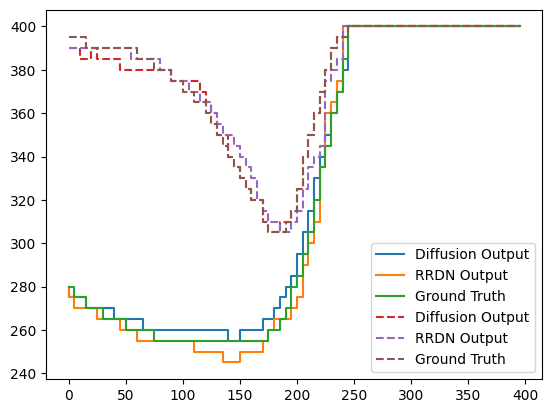

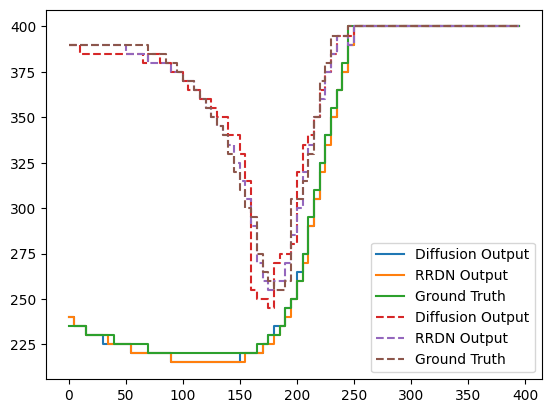

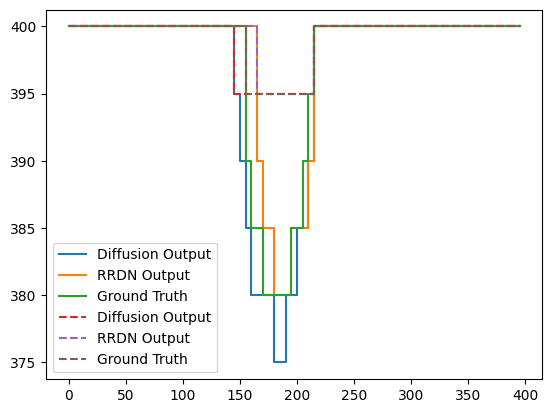

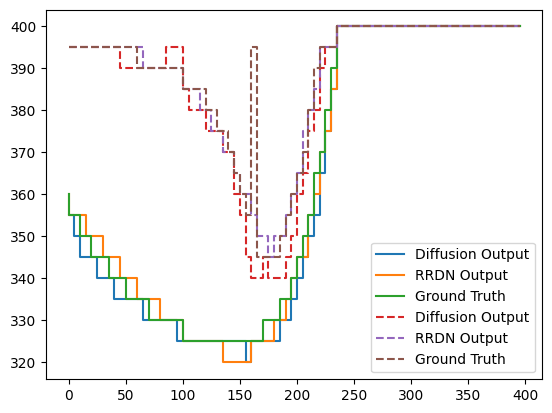

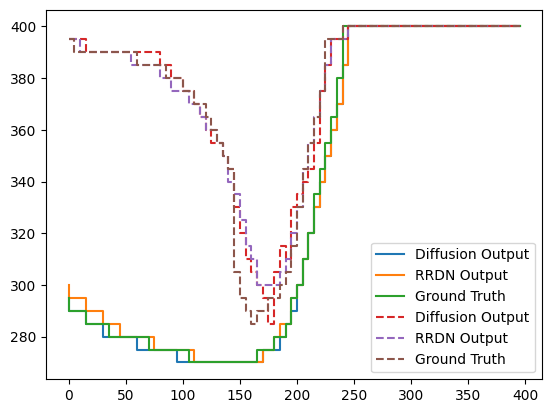

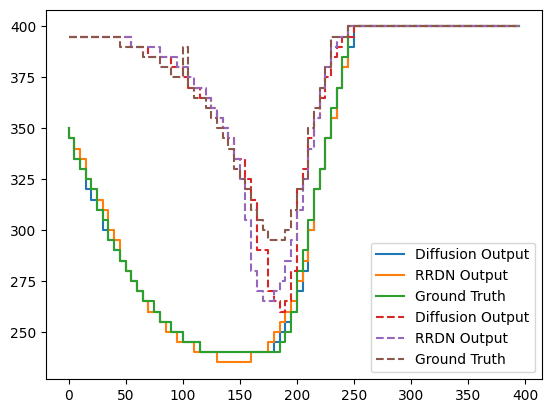

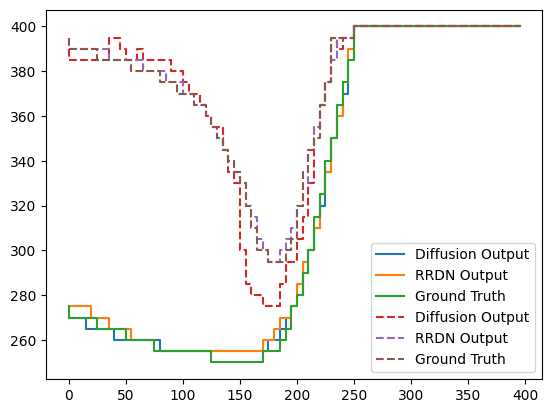

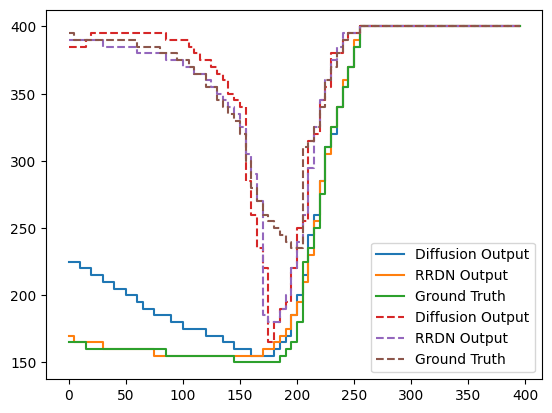

In [31]:
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dataloader):
    input, result_enc, target = predict_lrenc(lr_enc, res, hr, lr, upscaled_lr, dev_dataset)
    input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset, timesteps = 200, schedule = 'linear')
    for i in range(len(input)):
        profile_enc, kp_enc = get_profile(result_enc[i])
        profile_diff, kp_diff = get_profile(result_diffusion[i])
        profile_gt, kp_gt = get_profile(target[i])
        plt.step(np.arange(80)*5, 5*profile_diff, label = 'Diffusion Output')
        plt.step(np.arange(80)*5, 5*profile_enc, label = 'RRDN Output')
        plt.step(np.arange(80)*5, 5*profile_gt, label = 'Ground Truth')

        # plt.legend()
        # plt.show()
        plt.step(np.arange(80)*5, 5*kp_diff,'--',  label = 'Diffusion Output')
        plt.step(np.arange(80)*5, 5*kp_enc, '--', label = 'RRDN Output')
        plt.step(np.arange(80)*5, 5*kp_gt, '--', label = 'Ground Truth')

        plt.legend()
        plt.show()
    break
    

200 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 200, Schedule = linear


sampling loop time step: 100%|██████████| 200/200 [00:12<00:00, 15.77it/s]


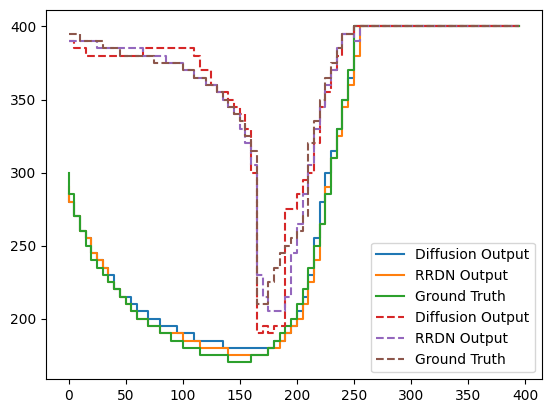

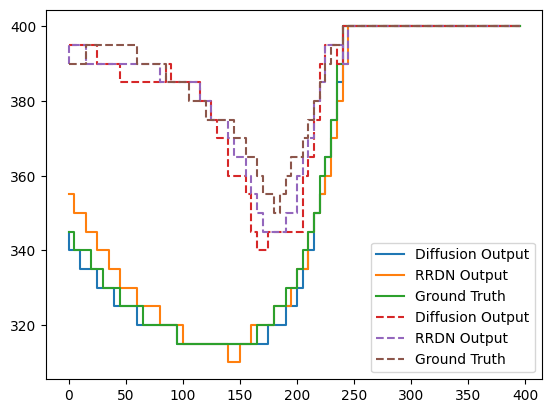

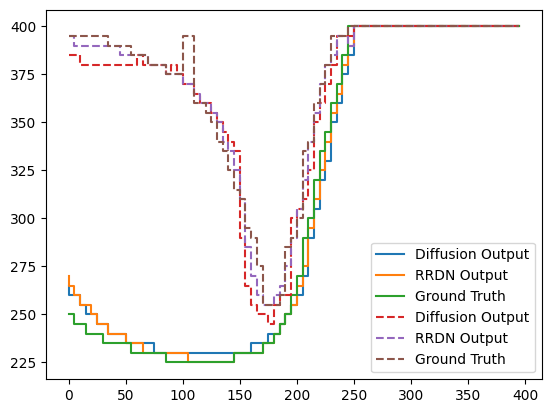

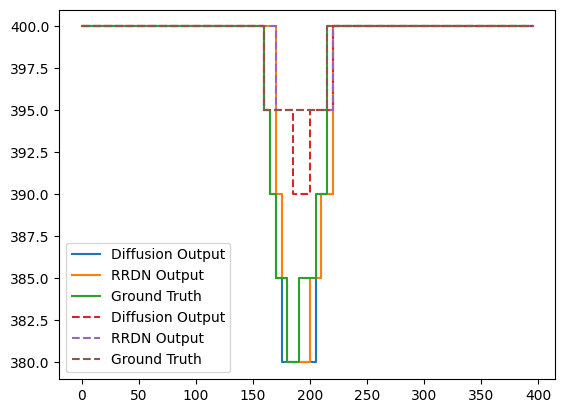

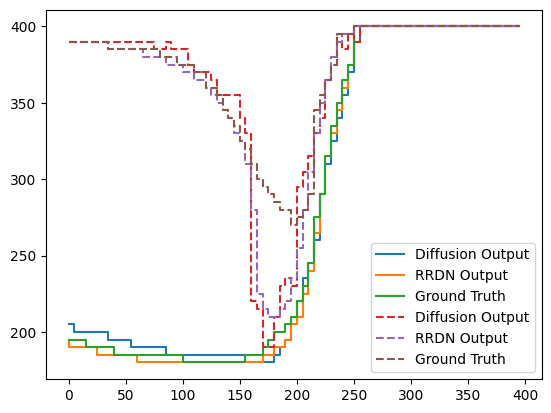

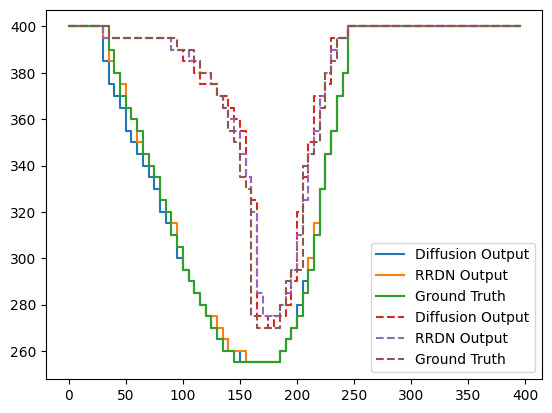

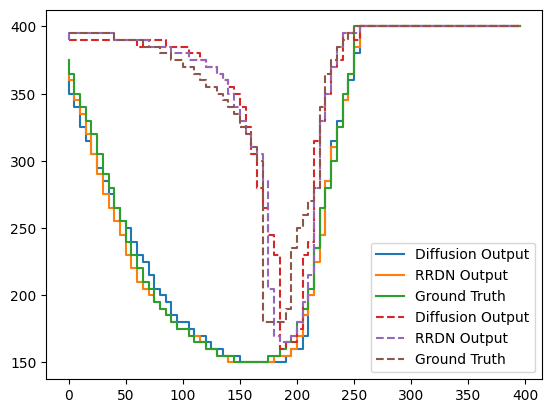

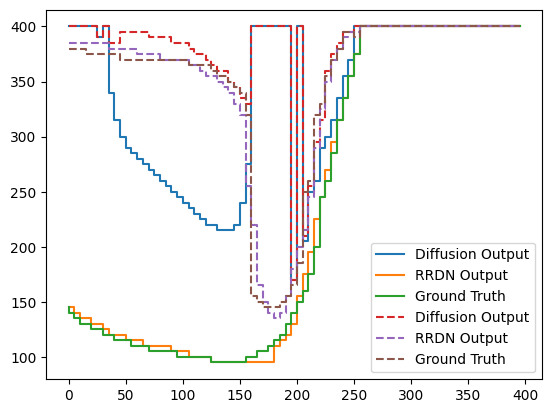

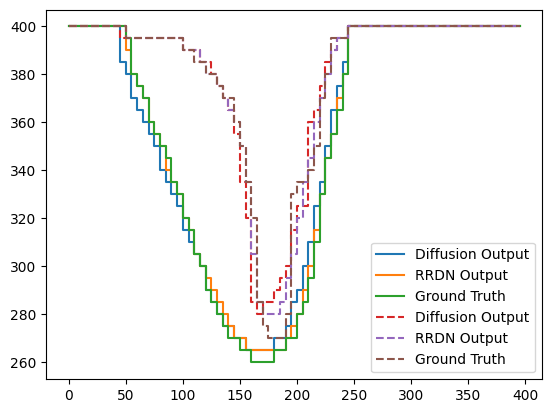

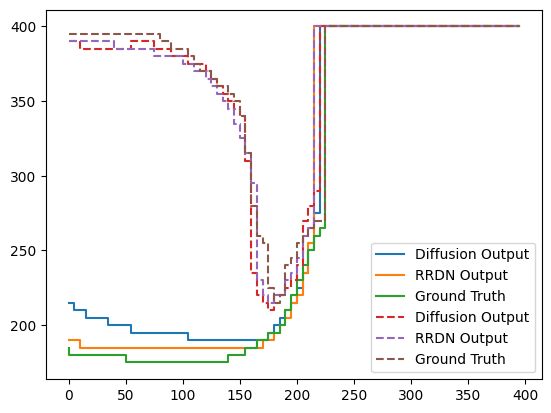

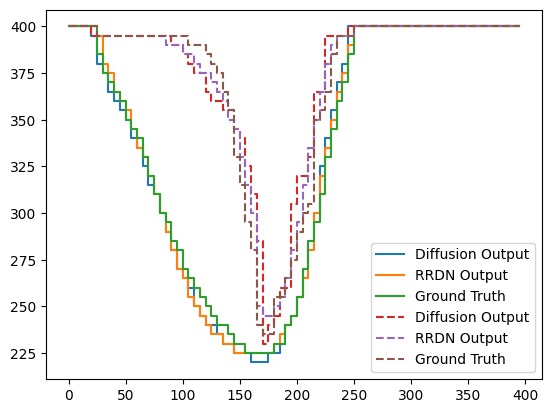

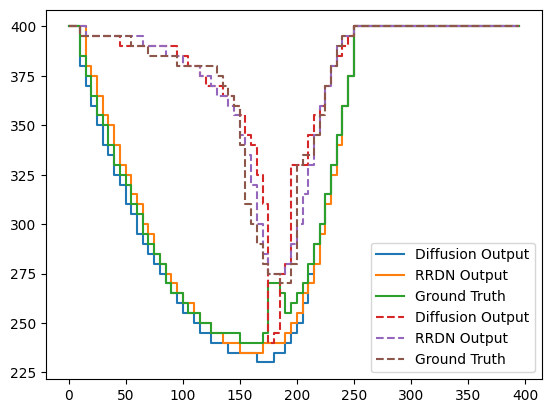

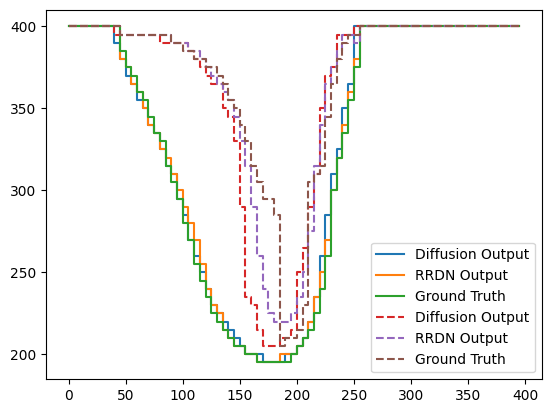

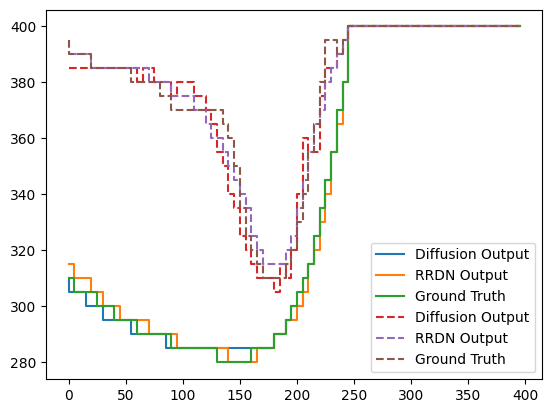

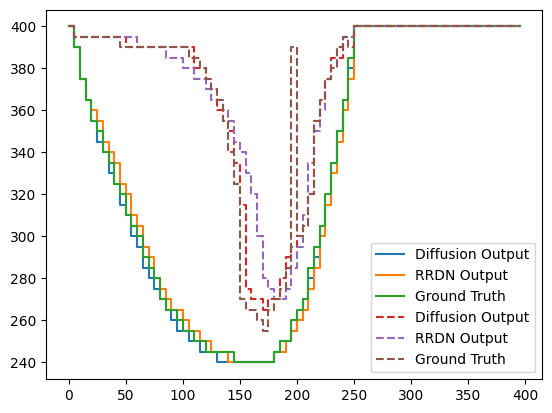

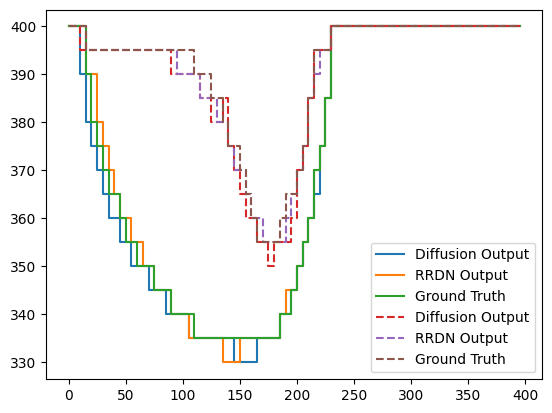

In [32]:
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):
    input, result_enc, target = predict_lrenc(lr_enc, res, hr, lr, upscaled_lr, dev_dataset)
    input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset, timesteps = 200, schedule = 'linear')
    for i in range(len(input)):
        profile_enc, kp_enc = get_profile(result_enc[i])
        profile_diff, kp_diff = get_profile(result_diffusion[i])
        profile_gt, kp_gt = get_profile(target[i])
        plt.step(np.arange(80)*5, 5*profile_diff, label = 'Diffusion Output')
        plt.step(np.arange(80)*5, 5*profile_enc, label = 'RRDN Output')
        plt.step(np.arange(80)*5, 5*profile_gt, label = 'Ground Truth')

        # plt.legend()
        # plt.show()
        plt.step(np.arange(80)*5, 5*kp_diff,'--',  label = 'Diffusion Output')
        plt.step(np.arange(80)*5, 5*kp_enc, '--', label = 'RRDN Output')
        plt.step(np.arange(80)*5, 5*kp_gt, '--', label = 'Ground Truth')

        plt.legend()
        plt.show()
    break

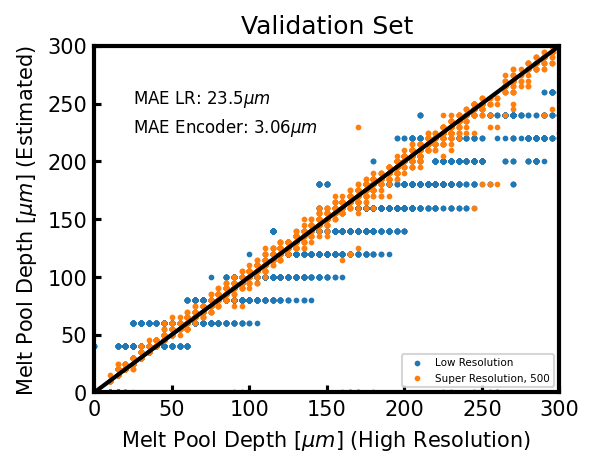

In [16]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
kps_depth = []
maes_depth = []

for max_depth, sim in zip(max_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    # print(mae_depth_diff, max_depth)
    # kps_depth.append()
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE Encoder: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

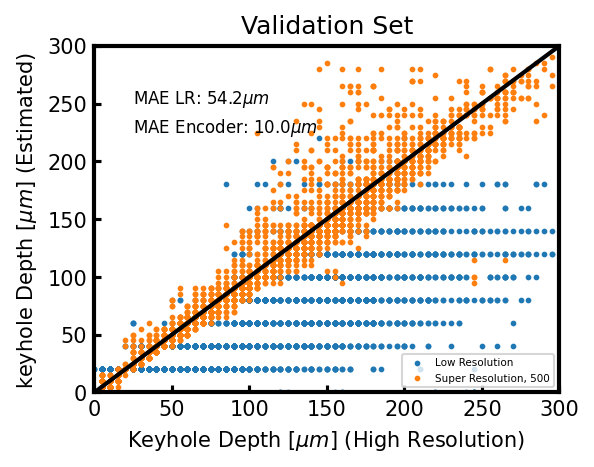

In [18]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for kp_depth, sim in zip(kp_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(kp_depth_gt, kp_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
    mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth)
    maes_depth.append(mae_depth_diff)
    # print(mae_depth_diff, kp_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE Encoder: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

## Benchmark Diffusion Model Keyhole/Melt Pool Dimensions

In [40]:

def SSIM(op, t, batch_size):
    ssim = 0 
    # print(op.shape, t.shape)
    
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[i][0].detach().cpu().numpy(), t[i][0].detach().cpu().numpy())#, full=True)
        else:
            score = ssim_id(op[i][0], t[i][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim



# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
psnrs_lr = []
psnrs_diff= []

ssims_diff = []
ssims_lr = []

l1_lr = []
l1_diff = []

sample_times = []
steps_list= []
psnr_mean_lr = []
ssim_mean_lr = []
l1_mean_lr = []
ssim_mean_diff = []
psnr_mean_diff = []
l1_mean_diff = []
l1loss = nn.L1Loss()
# sample_diff_steps = [50, 100,200, 500, 1000, 1500, 2000]
sim = simlinear2000
for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
    model = load_diffusion(sim.folder)
    diff_steps = sim.diff_steps
# for diff_steps in sample_diff_steps:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    psnr_batches_lr = []
    psnr_batches_diff = []
    l1_batches_diff = []
    l1_batches_lr = []
    ssim_batches_lr = []
    ssim_batches_diff = []

    for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dataloader):  
        oldtime = time.time()
        input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dev_dataset, timesteps =diff_steps)
        # print(result_diffusion.shape)
        upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
        lrpsnr = PSNR(upscale, target, target.shape[0]).item()

        diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
        # print(lrpsnr, diffpsnr)
        psnr_batches_diff.append(diffpsnr)
        psnr_batches_lr.append((lrpsnr))
        lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
        diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
        lrl1 = l1loss(upscale, target)
        # print('shape printing here')
        # print(type(result_diffusion), type(target))
        # print(result_diffusion.shape, target.shape)
        diffl1 = l1loss(torch.tensor(result_diffusion), target)
        # print('LR SSIM: ',  SSIM(upscale, target.view(upscale.shape), target.shape[0]))
        # print(result_diffusion.shape, target.shape, 'shapes result diffusion target')
        # print('Diffusion SSIM: ',  SSIM(result_diffusion, target.view(upscale.shape), target.shape[0]))
        ssim_batches_lr.append(lrssim)
        ssim_batches_diff.append(diffssim)
        l1_batches_lr.append(lrl1)
        l1_batches_diff.append(diffl1)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(diff_steps)
            profile_diff, kp_diff = get_profile(result_diffusion[i])
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i])
            profile_input, kp_input = get_profile(input[i], mesh = 20)
            # plt.imshow(target[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.imshow(result_diffusion[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.plot(profile_diff)
            # plt.plot(profile_gt)
            # # plt.plot(profile_input)
            # plt.show()


            max_depth_gt.append(5*(80-np.min(profile_gt)))
            max_depth_diff.append(5*(80-np.min(profile_diff)))
            max_depth_input.append(20*(20-np.min(profile_input)))
            kp_depth_gt.append(5*(80-np.min(kp_gt)))
            kp_depth_input.append(20*(20-np.min(kp_input)))
            kp_depth_diff.append(5*(80-np.min(kp_diff)))



        # plt.plot(profile_diff)
        # plt.show()
        # if batch_idx > 9:
        #     break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)
    ssims_diff.append(ssim_batches_diff)
    ssims_lr.append(ssim_batches_lr)
    l1_lr.append(l1_batches_lr)
    psnrs_lr.append(psnr_batches_lr)
    psnrs_diff.append(psnr_batches_diff)
    l1_diff.append(l1_batches_diff)
    psnr_mean_lr.append(np.mean(psnr_batches_lr))
    psnr_mean_diff.append(np.mean(psnr_batches_diff))
    ssim_mean_diff.append(np.mean(ssim_batches_diff))
    ssim_mean_lr.append(np.mean(ssim_batches_lr))
    l1_mean_lr.append(np.mean(l1_batches_lr))
    l1_mean_diff.append(np.mean(l1_batches_diff))
    
    print(ssim_mean_lr)



500 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 500, Schedule = linear


sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]/home/oogoke/DiffusionSR/models/diffusion_model.py:284: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x=torch.tensor(x,dtype=torch.float)
sampling loop time step: 100%|██████████| 500/500 [00:31<00:00, 15.88it/s]


500 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 500, Schedule = linear


sampling loop time step: 100%|██████████| 500/500 [00:32<00:00, 15.62it/s]


500 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 500, Schedule = linear


...

sampling loop time step: 100%|██████████| 2000/2000 [02:11<00:00, 15.25it/s]


2000 [1] 16
torch.Size([16, 64, 80, 80])
TIMESTEPS == 2000, Schedule = linear


sampling loop time step:  17%|█▋        | 339/2000 [00:22<01:49, 15.20it/s]


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3378, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_194408/2643934080.py", line 69, in <module>
    input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dev_dataset, timesteps =diff_steps)
  File "/home/oogoke/DiffusionSR/analysis/analysis_functions.py", line 353, in predict_modified_diffusion
    steps = timesteps + 1
  File "/home/oogoke/DiffusionSR/analysis/analysis_functions.py", line 353, in <lambda>
    steps = timesteps + 1
  File "/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/torch/autograd/grad_mode.py", line 28, in decorate_context
    return func(*args, **kwargs)
  File "/home/oogoke/DiffusionSR/analysis/analysis_functions.py", line 314, in sample
  File "/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/t

In [47]:
print(psnr_mean_lr)
print(psnr_mean_diff)
print(ssim_mean_lr)
print(ssim_mean_diff)
print(l1_mean_lr)
print(l1_mean_diff)



[21.08873836864608, 21.097069221202148, 21.097069221202148]
[26.98994427781645, 27.77065144439617, 26.88982750847468]
[0.7221770243246649, 0.7223038566287776, 0.7223038566287776]
[0.635102729692935, 0.6852876347142417, 0.6926370572579346]
[224.8383497541609, 224.81615136166536, 224.81615136166536]
[58.857212424926146, 47.27926502814098, 55.11391773146763]


In [15]:
# plt.plot(sample_diff_steps,psnr_mean_lr)
# plt.plot(sample_diff_steps, psnr_mean_diff)

# ssims_lr
# ssims_diff
import json

In [43]:
outpath = "trained_steps_train_psnrs_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_diff))
outpath = "trained_steps_train_psnrs_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_lr))
outpath = "trained_steps_train_ssims_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(ssims_diff))
outpath = "trained_steps_train_ssims_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(ssims_lr))
outpath = "trained_steps_train_l1_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(l1_lr_numpy))
outpath = "trained_steps_train_l1_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(l1_diff_numpy))

In [27]:
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)
def np_encoder(object):
    if isinstance(object, np.generic):
        return object.item()


In [44]:
outpath = "kp_diff_train.json"
with open(outpath, 'w') as f:
    # print(kp_depth_diffs)
    f.write(json.dumps([[float(l) for l in l1d] for l1d in kp_depth_diffs]))
outpath = "mp_diff_train.json"
with open(outpath, 'w') as f:
    f.write(json.dumps([[float(l) for l in l1d] for l1d in max_depth_diffs]))
    # f.write(json.dumps(max_depth_diffs), cls=np_encoder)
outpath = "mp_input_train.json"
with open(outpath, 'w') as f:
    f.write(json.dumps([float(l1d) for l1d in max_depth_input]))
    
    # f.write(json.dumps(max_depth_input), cls=np_encoder)
outpath = "kp_input_train.json"
with open(outpath, 'w') as f:
    f.write(json.dumps([float(l1d)  for l1d in kp_depth_input]))

    # f.write(json.dumps(kp_depth_input), cls=np_encoder)
outpath = "kp_gt_train.json"
with open(outpath, 'w') as f:
    f.write(json.dumps([float(l1d) for l1d in kp_depth_gt]))

    # f.write(json.dumps(kp_depth_gt), cls=np_encoder)
outpath = "mp_gt_train.json"
with open(outpath, 'w') as f:
    f.write(json.dumps([float(l1d) for l1d  in max_depth_gt]))

    # f.write(json.dumps(max_depth_gt), cls=np_encoder)


In [23]:
kp_depth_diffs

[[125,
  10,
  45,
  160,
  5,
  35,
  25,
  85,
  65,
  60,
  45,
  300,
  245,
  5,
  25,
  140,
  125,
  85,
  100,
  115,
  135,
  185,
  85,
  65,
  10,
  55,
  115,
  35,
  145,
  225,
  145,
  235,
  110,
  240,
  95,
  125,
  130,
  235,
  60,
  130,
  95,
  70,
  5,
  165,
  215,
  70,
  25,
  60,
  100,
  5,
  125,
  260,
  175,
  60,
  55,
  125,
  170,
  65,
  215,
  70,
  55,
  140,
  5,
  40,
  55,
  120,
  5,
  125,
  100,
  65,
  120,
  10,
  90,
  110,
  120,
  140,
  55,
  250,
  195,
  20,
  105,
  135,
  10,
  180,
  5,
  180,
  130,
  195,
  60,
  180,
  85,
  215,
  40,
  230,
  5,
  10,
  100,
  185,
  100,
  130,
  175,
  260,
  80,
  130,
  60,
  250,
  165,
  125,
  130,
  50,
  30,
  50,
  115,
  185,
  135,
  55,
  5,
  155,
  130,
  180,
  60,
  175,
  190,
  5,
  90,
  10,
  55,
  60,
  125,
  190,
  5,
  85,
  15,
  60,
  5,
  180,
  170,
  105,
  40,
  175,
  40,
  40,
  160,
  105,
  190,
  25,
  5,
  120,
  50,
  205,
  235,
  220,
  230,
  55,
  35,
 

In [42]:
l1_diff_numpy = [[l.item() for l in l1d] for l1d in l1_diff]
l1_lr_numpy = [[l.item() for l in l1d] for l1d in l1_lr]

In [83]:
outpath = "psnr_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_lr))

Text(0.5, 1.0, 'DDPM Sampling, Validation data')

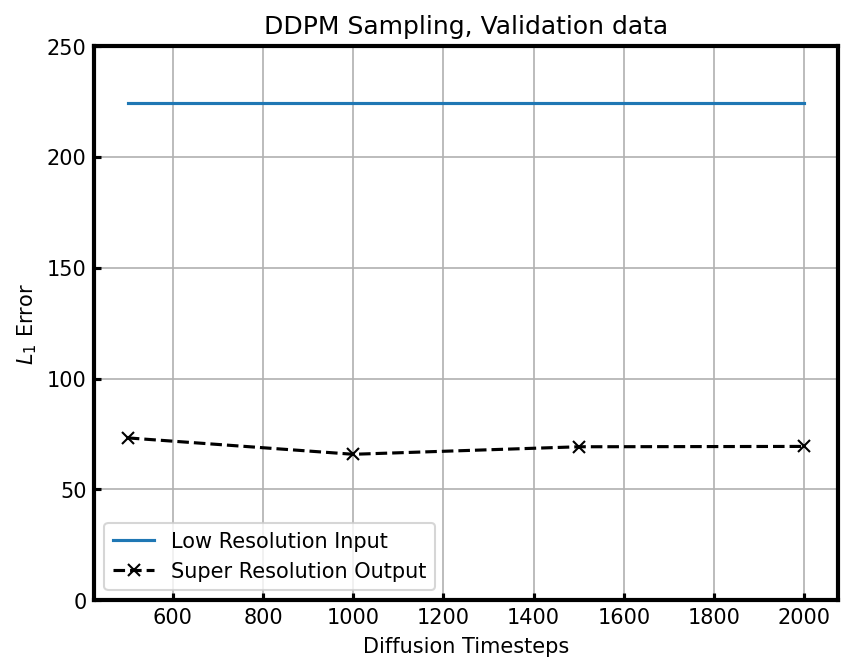

In [82]:
plt.figure(dpi =150)
frame_tick()
ssims_diff_loaded = json.load(open('trained_steps_dev_l1_diff.json'))
ssims_loaded = [np.mean(load) for load in ssims_diff_loaded]
ssims_lr=  json.load(open('trained_steps_dev_l1_lr.json'))
# print(len(ssims_lr))
ssims_lr_mean = [np.mean(load) for load in ssims_lr]
plt.plot([500, 1000, 1500, 2000], ssims_lr_mean, label = 'Low Resolution Input')
plt.plot([500, 1000, 1500, 2000], ssims_loaded, 'kx--', label = 'Super Resolution Output')
plt.ylim([0,250])
# plt.xlim([500, 2050])
# plt.plot([1, 2, 3, 5, 10, 15, 20, 50], ssim_mean_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')
# plt.plot([1, 2, 3, 5, 10, 15, 20, 50], ssim_mean_diff, 'kx--', label = 'Super Resolution Output')
# plt.ylim([0, 1])
plt.legend()
plt.xlabel('Diffusion Timesteps')
# plt.xlim([0,52])
plt.ylabel(r'$L_1$ Error')
plt.grid()
plt.title("DDPM Sampling, Validation data")

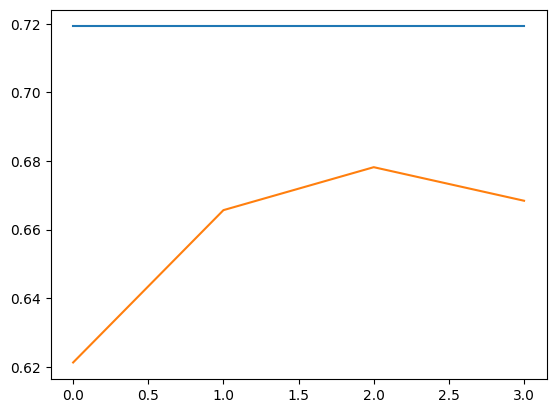

In [21]:
plt.plot(ssim_mean_lr)
plt.plot(ssim_mean_diff)

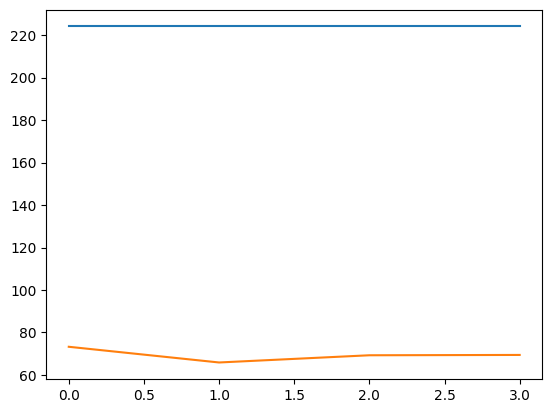

In [20]:
plt.plot(l1_mean_lr)
plt.plot(l1_mean_diff)

In [17]:
# kp_depth_diffs# get_inst_profile(result_diffusion)
# batch_idx
sample_times

[3.339805841445923,
 3.342054605484009,
 3.3440563678741455,
 3.3460693359375,
 3.3480310440063477,
 3.3499579429626465,
 3.351686954498291,
 3.3536338806152344,
 3.355633497238159,
 3.357562780380249,
 3.35953426361084,
 3.3612213134765625,
 3.362414598464966,
 3.3647592067718506,
 3.3667795658111572,
 3.3688106536865234,
 6.575289011001587,
 6.577375650405884,
 6.5792553424835205,
 6.581094741821289,
 6.582955837249756,
 6.584723711013794,
 6.5864479541778564,
 6.588303565979004,
 6.590148687362671,
 6.5919153690338135,
 6.594189167022705,
 6.595767974853516,
 6.596806764602661,
 6.598414659500122,
 6.600250244140625,
 6.602455377578735,
 13.196335554122925,
 13.19843864440918,
 13.200446605682373,
 13.202380418777466,
 13.204374551773071,
 13.206165790557861,
 13.207773685455322,
 13.209745168685913,
 13.211658477783203,
 13.213448524475098,
 13.215288400650024,
 13.216886520385742,
 13.217946290969849,
 13.220357656478882,
 13.222468137741089,
 13.224223613739014,
 32.9338076114654

ValueError: x and y must be the same size

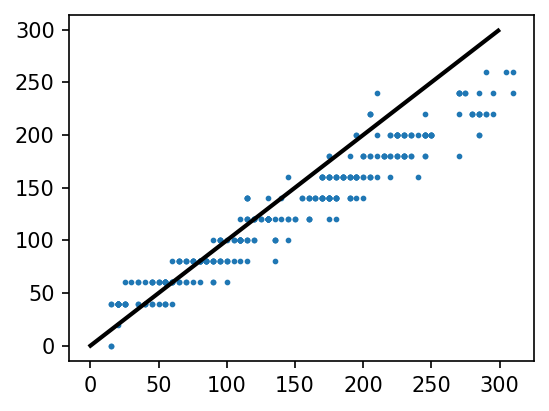

In [48]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for max_depth, sim in zip(max_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, max_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [52]:
# len(max_depth_gt
3040/336

9.047619047619047

ValueError: x and y must be the same size

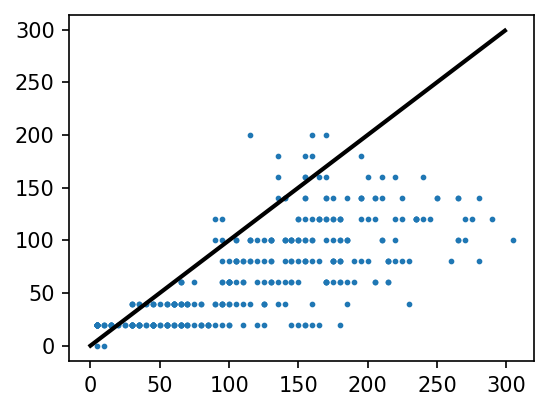

In [46]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for kp_depth, sim in zip(kp_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(kp_depth_gt, kp_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
    mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, kp_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

3.825 [160, 20, 55, 200, 20, 45, 45, 120, 85, 85, 70, 305, 250, 20, 45, 155, 135, 100, 120, 145, 180, 205, 100, 95, 30, 85, 145, 60, 175, 245, 175, 245, 120, 260, 110, 135, 165, 260, 90, 155, 115, 105, 20, 190, 255, 85, 50, 70, 130, 20, 140, 270, 190, 85, 75, 130, 195, 95, 240, 80, 80, 165, 20, 55, 60, 160, 20, 155, 120, 110, 125, 30, 105, 130, 190, 150, 80, 260, 215, 30, 130, 160, 30, 190, 30, 195, 135, 235, 80, 210, 165, 225, 60, 245, 20, 35, 115, 195, 125, 150, 180, 270, 90, 200, 80, 285, 175, 140, 155, 75, 50, 65, 145, 200, 150, 80, 15, 170, 210, 185, 80, 185, 225, 20, 115, 20, 70, 80, 180, 240, 20, 90, 30, 80, 15, 215, 195, 115, 65, 210, 55, 50, 175, 130, 200, 50, 20, 170, 75, 220, 260, 230, 275, 85, 50, 170, 20, 30, 55, 185, 100, 275, 210, 90, 175, 120, 100, 100, 150, 195, 145, 240, 70, 85, 65, 35, 135, 150, 185, 145, 70, 75, 185, 255, 215, 230, 80, 30, 160, 170, 225, 265, 80, 25, 155, 225, 20, 30, 245, 75, 230, 170, 75, 80, 200, 35, 15, 70, 55, 90, 190, 185, 60, 160, 165, 175, 1

TypeError: append() takes exactly one argument (0 given)

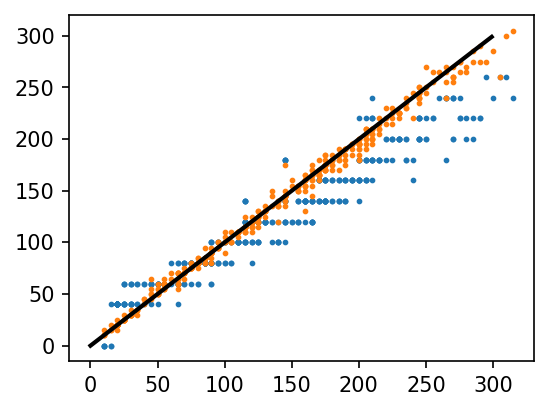

In [18]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
kps_depth = []
maes_depth = []

for max_depth, sim in zip(max_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, max_depth)
    kps_depth.append()
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

ValueError: x and y must have same first dimension, but have shapes (8,) and (4,)

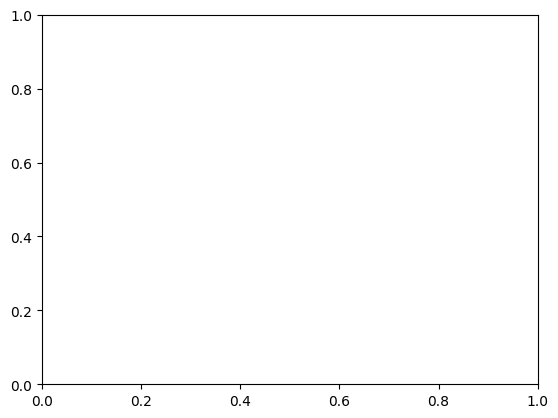

In [22]:
plt.plot(steps_list[::12], maes_depth, '.')
frame_tick()
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
plt.show()
frame_tick()

plt.plot(steps_list[::12], sample_times[::12], '.')
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'Elapsed Time (s)')
plt.show()


plt.plot(steps_list[::12], maes_depth, '.')
frame_tick()
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
plt.show()
frame_tick()


NameError: name 'kp_depth_enc' is not defined

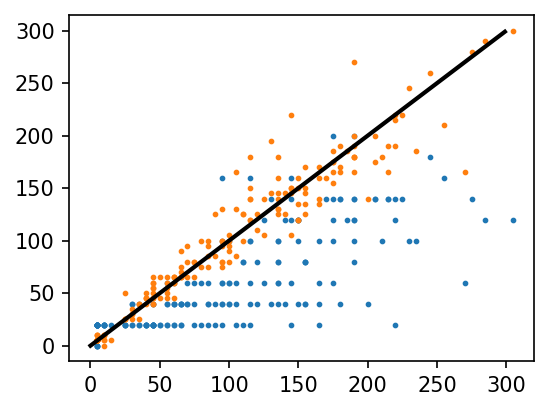

In [20]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_mbn, s = 3.0, label = 'Super Resolution')


mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth_diff)
mae_depth_enc = mean_absolute_error(kp_depth_gt, kp_depth_enc)
mae_depth_mbn = mean_absolute_error(kp_depth_gt, kp_depth_mbn)
plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )   
plt.show()

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth_enc)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
plt.show()

In [ ]:
def plot_temp_lines(input, result, target, modeltype, split = 'train'):
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'direct'
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.title(r'{} model, Cross section: x = 200 $\mu m$'.format(modeltype))
    plt.plot(80*5*(np.arange(input.shape[-1])/input.shape[-1]),input[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),target[40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),result[40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()
plot_temp_lines(input, result_diffusion[0], target[0][0], split = 'test', modeltype = "Diffusion")
plot_temp_lines(input, lr_enc_result[0][0], target[0][0], split = 'test', modeltype = "Encoder")


In [ ]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct'):
    profile_result, kp_result = get_profile(result)

    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20), kp_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), kp_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80), kp_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), profile_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()
input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
print(input.shape)
input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, train_dataset)
input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, train_dataset)
plot_srdiff_contours(input, result_diffusion, target[0], split = 'Train', modeltype = "Diffusion")
plot_srdiff_contours(input, lr_enc_result, target[0], split = 'Train', modeltype = "Encoder")
plot_srdiff_contours(input, result_mobilenet, target[0], split = 'Train', modeltype = "MobileNet")


plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder")
plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Train', modeltype = "MobileNetSISR")
plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion")


In [ ]:
profile_result, kp_result = get_profile(result_diffusion)
profile_mbn_result, kp_mbn_result = get_profile(result_mobilenet)
profile_enc_result, kp_enc_result = get_profile(lr_enc_result)
plt.step(5*np.arange(80), profile_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_enc_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_mbn_result - 400, label = 'Super Resolution (Output)' )


In [ ]:
lrpsnrs = []

lrencpsnrs = []
diffpsnrs = []
mobilenetpsnrs = []
lrl1loss = []
lrencl1loss = []
diffl1loss = []
mobilenetl1loss= []
mobilenetssims = []
lrssims = []
diffssims = []
lrencssims = []


def SSIM(op, t, batch_size):
    ssim = 0 
    print(op.shape, t.shape)
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[0][0].detach().cpu().numpy(), t[0][0].detach().cpu().numpy())#, full=True)
        else:
            print(op[0].shape,t[0][0].detach().cpu().numpy().shape)
            score = ssim_id(op[0], t[0][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
l1loss = nn.L1Loss()
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)
    print(input.shape)
    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, dev_dataset)
    
    lrpsnr = PSNR(upscale, target, target.shape[0]).item()
    lrencpsnr = PSNR(lr_enc_result, target, target.shape[0]).item()

    diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()

    mobilenetpsnr = PSNR(result_mobilenet, target, target.shape[0]).item()

    print('LR PSNR: ', lrpsnr)
    print('LR enc PSNR: ',PSNR(lr_enc_result, target, target.shape[0])) 
    print('Diffusion PSNR: ',PSNR(result_diffusion, target, target.shape[0])) 
    print('MobileNet PSNR: ',PSNR(result_mobilenet, target, target.shape[0])) 
    print('LR SSIM: ',  SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0]))
    print('LR enc SSIM: ',  SSIM(lr_enc_result, target, target.shape[0]))
    print('Diffusion SSIM: ',  SSIM(result_diffusion, target, target.shape[0]))
    print('MobileNet SSIM: ',  SSIM(result_mobilenet, target, target.shape[0]))
    lrssim = SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0])
    lrencssim = SSIM(lr_enc_result, target, target.shape[0])
    diffssim = SSIM(result_diffusion, target, target.shape[0])
    mobilenetssim = SSIM(result_mobilenet, target, target.shape[0])

    (lr_enc_result, target)
    lrpsnrs.append(lrpsnr)
    lrencpsnrs.append(lrencpsnr)
    diffpsnrs.append(diffpsnr)
    lrssims.append(lrssim)#SSIM(lr_enc_result.view(lr_enc_result.shape[0],1 , lr_enc_result.shape[1], lr_enc_result.shape[2]), target, target.shape[0]))
    lrencssims.append(lrencssim)

    diffssims.append(diffssim)
    mobilenetssims.append(mobilenetssim)


    mobilenetpsnrs.append(mobilenetpsnr)
    lrl1loss.append(l1loss(upscale, target[:,0]).item())
    lrencl1loss.append(l1loss(lr_enc_result[:,0], target[:,0]).item())
    diffl1loss.append(l1loss(torch.tensor(result_diffusion), target[:,0]).item())
    mobilenetl1loss.append(l1loss(torch.tensor(result_mobilenet[:,0]), target[:,0]).item())





In [ ]:
isinstance(lr_enc_result, torch.Tensor)

In [ ]:
print(np.mean(lrl1loss))

In [ ]:
print(np.mean(lrencl1loss))

In [ ]:
print(np.mean(diffl1loss))

In [ ]:
print(np.mean(diffssims))
print(np.mean(mobilenetssims))
print(np.mean(lrencssims))
print(np.mean(lrssims))


In [ ]:
print(np.mean(mobilenetl1loss))


In [ ]:
np.mean(lrpsnrs)


In [ ]:
np.mean(lrencpsnrs)


In [ ]:
np.mean(mobilenetpsnr)


In [ ]:
np.mean(diffpsnrs)


In [ ]:
from skimage.metrics import structural_similarity as ssim_id
def SSIM(op, t, batch_size):
    ssim = 0 
    for i in range(op.shape[0]):

        score = ssim_id(op[0], t[0])#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
print('LR SSIM: ',  SSIM(lr_data, hr, hr.shape[0]))
print('SR SSIM: ',  SSIM(generated_hr, hr, hr.shape[0]))